The angles of each joints are :  [0.0, 9.154095988448834, 4.828883074954735, -3.4915877129673656, -10.989318955362851, -0.1861308754772122, -9.149799598130986]
Computed position: [ 2.19998343e-01 -2.23116797e-07  3.79999783e-01], original position : [0.22, 0.0, 0.38]
Computed position (readable) : ['0.22', '-0.00', '0.38']


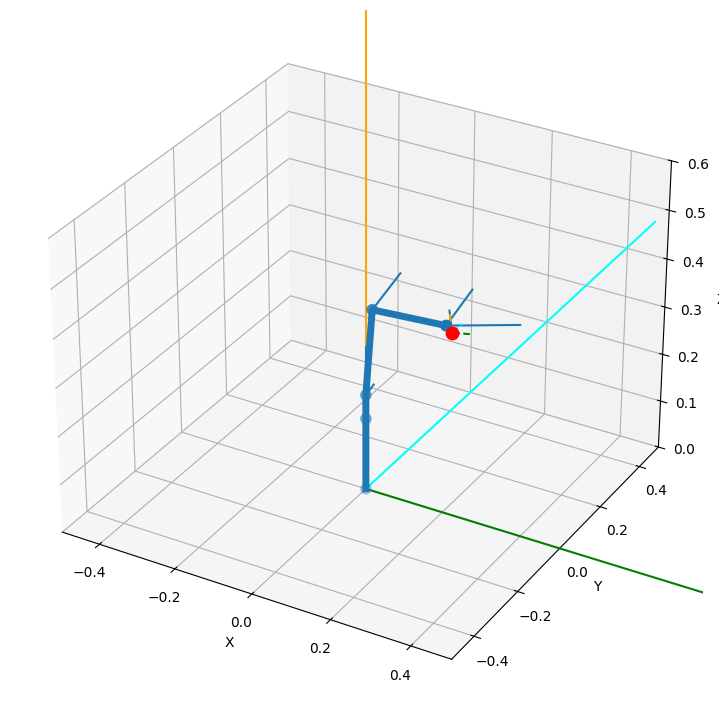

In [3]:
# https://github.com/robko01/robko01_ros2/blob/main/urdf/robko01.urdf
# https://www.geeksforgeeks.org/how-to-install-jupyter-notebook-in-linux/
# https://www.geeksforgeeks.org/using-matplotlib-with-jupyter-notebook/
# https://mymodelrobot.appspot.com/5629499534213120
# https://github.com/Phylliade/ikpy

import time
import math
import numpy as np
import ikpy.chain
import ikpy.utils.plot as plot_utils
# import serial

def compute(target_position, target_orientation):
    # Load the kinematics description.
    my_chain = ikpy.chain.Chain.from_urdf_file("urdf/robko01.urdf",active_links_mask=[False, True, True, True, True, True, True])
    
    # Inverst calculations.
    ik = my_chain.inverse_kinematics(target_position, target_orientation, orientation_mode="Y")
    print("The angles of each joints are : ", list(map(lambda r: math.degrees(r), ik.tolist())))
    
    # Forward calculations.
    computed_position = my_chain.forward_kinematics(ik)
    print("Computed position: %s, original position : %s" % (computed_position[:3, 3], target_position))
    print("Computed position (readable) : %s" % [ '%.2f' % elem for elem in computed_position[:3, 3] ])
    
    # Plot the data.
    # %matplotlib widget
    #%matplotlib widget
    import matplotlib.pyplot as plt
    fig, ax = plot_utils.init_3d_figure()
    fig.set_figheight(9)  
    fig.set_figwidth(13)  
    my_chain.plot(ik, ax, target=target_position)
    plt.xlim(-0.5, 0.5)
    plt.ylim(-0.5, 0.5)
    ax.set_zlim(0, 0.6)
    plt.ion()
    
# target positions.
# target_position = [ 0.175, 0.0, 0.380]
# target_position = [ 0.220, 0.0, 0.380]
target_position = [ 0.220, 0.0, 0.380]
target_orientation = [0, 0, 0]
compute(target_position, target_orientation)